In [1]:
# 第2章｜大盤參考哪條均線最有用：每次開啟 notebook，先執行這一格（安裝套件、登入 FinLab、開啟資料快取）
%pip install -q finlab==2.0.21 ta-lib==0.8.1
import finlab
from finlab import data

finlab.login()
data.set_storage(data.FileStorage())

Note: you may need to restart the kernel to use updated packages.


已登入（使用快取憑證）。


# 大盤參考哪條均線最有用？

**對應影片**：第 2 章 單元 2、3「大盤參考哪條均線最有用 Part 1、Part 2」

**和影片的差異**

| 影片（2018） | 新版教材 |
| --- | --- |
| 用大盤 1 分 K 算均線，報酬用指數點數相加 | 用加權指數日資料產生訊號，實際買賣 **0050**，用 `finlab.backtest.sim` 回測（含手續費與交易稅） |
| 自己寫迴圈計算持有部位與報酬 | 只要產生「每天持有與否」的表格，交給 `sim()` 計算 |
| 參數最佳化後直接看整段歷史 | 參數只在「訓練期間」挑選，再到「測試期間」驗證，避免過度最佳化 |

In [2]:
import itertools

import pandas as pd
from finlab.backtest import sim

## Part 1：哪一條均線最有用？

最簡單的均線策略：**加權指數站上 N 日均線就持有 0050，跌破就賣出**。

部位表的欄位名稱就是要買賣的股票代號。訊號用大盤計算，欄位命名成 `0050`，`sim()` 就會拿 0050 的價格計算報酬。
`sim()` 以每天收盤後的訊號，在下一個交易日收盤價成交。ETF 的證券交易稅是 0.1%（股票是 0.3%），回測時要設定 `tax_ratio`。

In [3]:
TRADE_STOCK = '0050'
ETF_TAX_RATIO = 0.001

taiex = data.get('taiex_total_index:收盤指數').rename(columns={'TAIEX': TRADE_STOCK})
taiex.tail()

symbol,0050
date,
2018-12-24,9639.70
2018-12-25,9527.09
2018-12-26,9478.99
2018-12-27,9641.56
2018-12-28,9727.41


In [4]:
STATS_FORMAT = {'CAGR': '{:.2%}', 'Max drawdown': '{:.2%}', 'Sharpe': '{:.2f}'}


def summarize(report) -> dict:
    """從回測報告取出最常看的三個指標：年化報酬率、最大回檔、夏普值。"""
    stats = report.get_stats()
    return {'CAGR': stats['cagr'], 'Max drawdown': stats['max_drawdown'], 'Sharpe': stats['daily_sharpe']}

In [5]:
MA_WINDOWS = [5, 10, 20, 60, 120, 240]

buy_and_hold = sim(taiex.notna(), name='Buy & hold 0050', tax_ratio=ETF_TAX_RATIO)
results = {'Buy & hold': summarize(buy_and_hold)}
curves = {'Buy & hold': buy_and_hold.creturn}

for window in MA_WINDOWS:
    position = taiex > taiex.average(window)
    report = sim(position, name=f'MA{window}', tax_ratio=ETF_TAX_RATIO)
    results[f'MA{window}'] = summarize(report)
    curves[f'MA{window}'] = report.creturn

pd.DataFrame(results).T.style.format(STATS_FORMAT)

,CAGR,Max drawdown,Sharpe
Buy & hold,5.65%,-55.75%,0.28
MA5,-11.18%,-78.13%,-0.99
MA10,-8.88%,-69.70%,-0.80
MA20,-5.65%,-56.00%,-0.55
MA60,2.14%,-24.15%,0.08
MA120,5.23%,-24.80%,0.32
MA240,2.99%,-26.77%,0.14


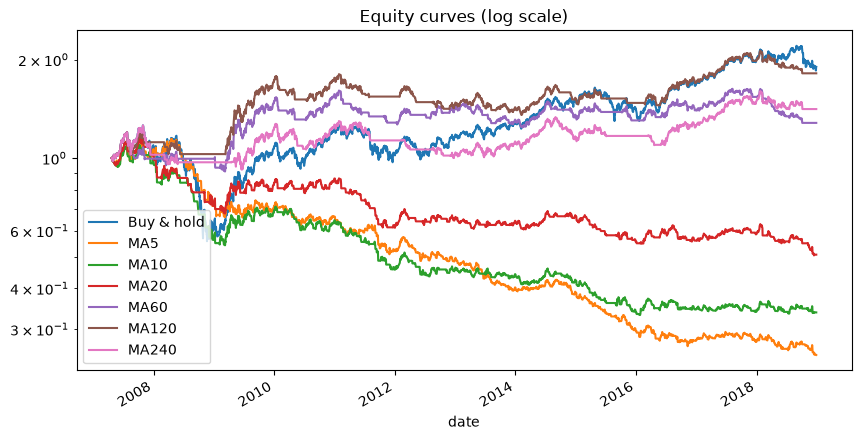

In [6]:
pd.DataFrame(curves).plot(figsize=(10, 5), logy=True, title='Equity curves (log scale)');

觀察重點：

- 短均線（5、10 日）進出很頻繁，每次買賣都要付手續費與交易稅，成本會吃掉報酬。
- 長均線進出次數少，而且能避開大跌段，最大回檔（Max drawdown）通常比買進持有小。

回測報告的互動圖表可以用 `report.display()` 查看。

## Part 2：乖離率通道策略與參數最佳化

影片中的乖離率通道策略：

- 乖離率 = 指數 ÷ N 日均線
- 上軌 = 1 + 乖離率近 M 日標準差 × K；下軌 = 1 − 乖離率近 M 日標準差 × K
- 乖離率突破上軌 → 進場；跌破下軌 → 出場

`entries.hold_until(exits)` 會在進場訊號出現時買進，一直持有到出場訊號出現。

In [7]:
def bias_band_position(ma_window: int, std_window: int, width: float) -> pd.DataFrame:
    bias = taiex / taiex.average(ma_window)
    band = bias.rolling(std_window).std() * width
    entries = bias > 1 + band
    exits = bias < 1 - band
    return entries.hold_until(exits)


report = sim(bias_band_position(ma_window=60, std_window=120, width=1), name='Bias band', tax_ratio=ETF_TAX_RATIO)
summarize(report)

{'CAGR': 0.01683208677579251,
 'Max drawdown': -0.2475656253723344,
 'Sharpe': 0.03834261725507607}

### 在訓練期間找最佳參數

參數試越多組，越容易找到「剛好適合過去」的組合。
所以我們把資料切成兩段：**訓練期間**用來挑參數，**測試期間**只用來檢查挑出來的參數是否依然有效。

In [8]:
TRAIN_END = '2015-12-31'
TEST_START = '2016-01-01'

MA_GRID = [20, 60, 120, 240]
STD_GRID = [60, 120, 240]
WIDTH_GRID = [0.5, 1.0, 1.5]

search = []
for ma_window, std_window, width in itertools.product(MA_GRID, STD_GRID, WIDTH_GRID):
    position = bias_band_position(ma_window, std_window, width)
    report = sim(position.loc[:TRAIN_END], tax_ratio=ETF_TAX_RATIO)
    search.append({'ma_window': ma_window, 'std_window': std_window, 'width': width, **summarize(report)})

search = pd.DataFrame(search).sort_values('Sharpe', ascending=False)
search.head(10).style.format(STATS_FORMAT)

,ma_window,std_window,width,CAGR,Max drawdown,Sharpe
26,120,240,1.500000,7.31%,-25.65%,0.44
18,120,60,0.500000,6.66%,-18.47%,0.41
20,120,60,1.500000,6.39%,-26.69%,0.40
21,120,120,0.500000,5.88%,-23.10%,0.36
7,20,240,1.000000,5.48%,-21.10%,0.32
9,60,60,0.500000,5.46%,-20.74%,0.32
2,20,60,1.500000,4.68%,-18.63%,0.29
12,60,120,0.500000,4.96%,-21.85%,0.29
32,240,120,1.500000,4.63%,-24.81%,0.26
10,60,60,1.000000,4.49%,-26.56%,0.26


### 到測試期間驗證

In [9]:
best = search.iloc[0]
best_position = bias_band_position(int(best['ma_window']), int(best['std_window']), best['width'])

validation = {
    'Best params (train)': summarize(sim(best_position.loc[:TRAIN_END], tax_ratio=ETF_TAX_RATIO)),
    'Best params (test)': summarize(sim(best_position.loc[TEST_START:], tax_ratio=ETF_TAX_RATIO)),
    'Buy & hold (test)': summarize(sim(taiex.notna().loc[TEST_START:], tax_ratio=ETF_TAX_RATIO)),
}
pd.DataFrame(validation).T.style.format(STATS_FORMAT)

,CAGR,Max drawdown,Sharpe
Best params (train),7.31%,-25.65%,0.44
Best params (test),9.52%,-8.75%,0.68
Buy & hold (test),11.42%,-15.99%,0.72


訓練期間的成績包含「挑參數的運氣」，不能當成未來的預期。
判斷策略要看測試期間，而且要和買進持有比較：報酬更高，或報酬接近但回檔更小，才值得採用。